In [2]:
import torch
import numpy as np
import anndata as ad
import matplotlib.pyplot as plt

from data.simulations import make_gaussian_to_moons
from data.dataset import CondFMDataset, ConditionBatch
from models.flow import CondFlow, ConditionEncoder, sample_ode
from training.losses import LossComposer, OTLoss, DensityLoss, EnergyLoss
from training.trainer_neural_ode import train_neural_ode

import plotly.graph_objects as go

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


In [5]:
# Read data
try:
    adata = ad.read_h5ad("gaussian_to_moons.h5ad")
except FileNotFoundError:
    print("Generating toy dataset...")
    adata = make_gaussian_to_moons(n_samples=2000)
    adata.write_h5ad("gaussian_to_moons.h5ad")

Generating toy dataset...


In [4]:
pert_ids = torch.tensor(adata.obs["perturbation"].values, dtype=torch.long)
condition_batch = ConditionBatch(perturbations=pert_ids, perturbation_covariates={}, sample_covariates={})

In [5]:
ds = CondFMDataset(
    adata,
    condition_batch,
    control_col="vehicle",
    control_value=1.0,
    use_pca=False,
    use_norm=False,
)

print(f"source shape: {ds.control_data.shape}, target shape: {ds.perturbed_data.shape}")

source shape: torch.Size([1000, 2]), target shape: torch.Size([2000, 2])


In [6]:
covariate_dicts = {
    "perturbation_num_categories": 3,
    "perturbation_covariates": {},
    "sample_covariates": {},
}
cond_enc = ConditionEncoder(covariate_dicts, embedding_dim=16)

model = CondFlow(
    input_dim=2,
    output_dim=2,
    hidden_dim=64,
    hidden_layers=3,
    cond_encoder=cond_enc,
)

model.to(device)

CondFlow(
  (cond_encoder): ConditionEncoder(
    (emb_pert): Embedding(3, 16)
    (emb_pert_cov): ModuleDict()
    (emb_sample_cov): ModuleDict()
    (proj_perturbation): Sequential(
      (0): Linear(in_features=16, out_features=64, bias=True)
      (1): ReLU()
    )
    (proj_pert_cov): ModuleDict()
    (proj_sample_cov): ModuleDict()
    (output_mlp): Sequential(
      (0): Linear(in_features=64, out_features=64, bias=True)
      (1): ReLU()
      (2): Linear(in_features=64, out_features=64, bias=True)
    )
  )
  (time_embed): GaussianFourierProjection()
  (input_layer): Linear(in_features=130, out_features=64, bias=True)
  (hidden_layers): ModuleList(
    (0-2): 3 x Linear(in_features=64, out_features=64, bias=True)
  )
  (output_layer): Linear(in_features=64, out_features=2, bias=True)
  (activation): ELU(alpha=1.0)
)

In [12]:
ot_loss = OTLoss()
density_loss = DensityLoss()
energy_loss = EnergyLoss()

loss_composer = LossComposer(
    loss_map={"ot": ot_loss, "density": density_loss, "energy": energy_loss},
    loss_weights={"ot": 1.0, "density": 10.0, "energy": 0.01},
)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

In [ ]:
history = train_neural_ode(
    model=model,
    dataset=ds,
    loss_composer=loss_composer,
    optimizer=optimizer,
    batch_size=128,
    epochs=50,  # Reduced for toy example ODE
    device=str(device),
    use_sampler=True,
    steps_per_epoch=20,  # Reduced for toy example ODE
    ode_method="midpoint",
    adjoint=False,
    n_energy_steps=10,
)

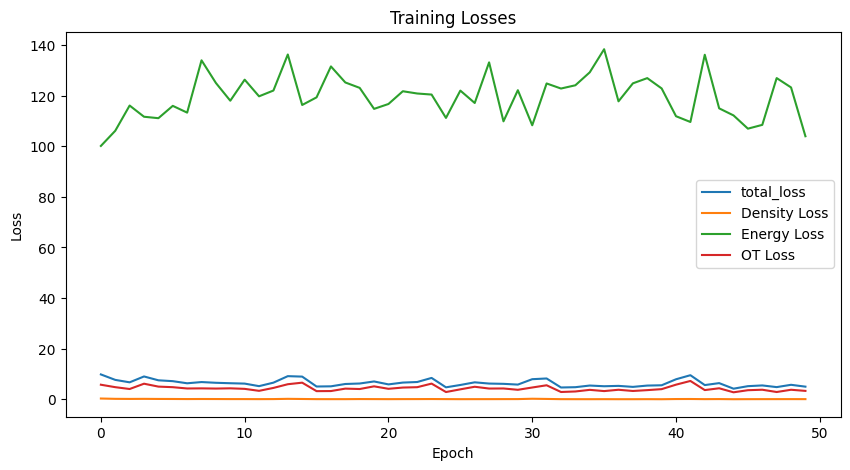

In [17]:
# plot loss
plt.figure(figsize=(10, 5))
plt.plot(history["train_loss"], label="total_loss")
plt.plot(history["individual_train_losses"]["density"], label="Density Loss")
plt.plot(history["individual_train_losses"]["energy"], label="Energy Loss")
plt.plot(history["individual_train_losses"]["ot"], label="OT Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Losses")
plt.legend()
plt.show()

In [18]:
# save model
torch.save(model.state_dict(), "toy_ode_model.pt")

Text(0.5, 1.0, 'neural ode on gaussian to moons (distribution matching)')

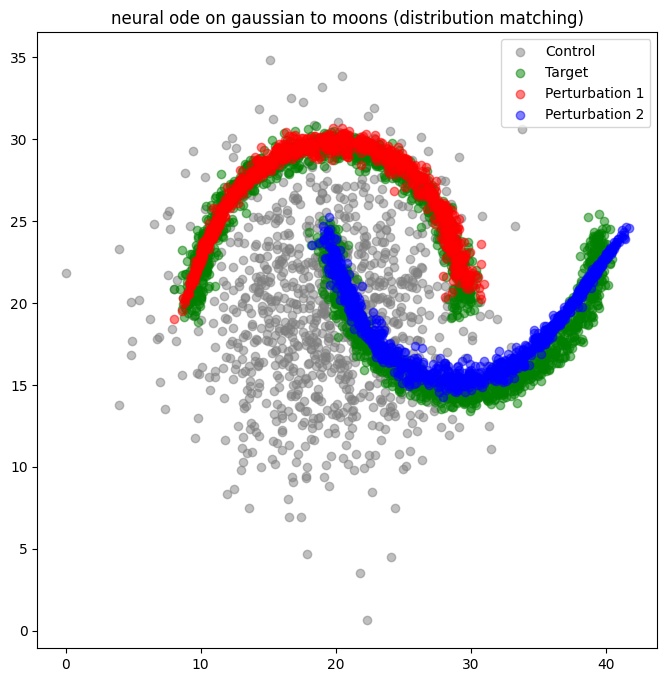

In [19]:
model.eval()
x_0 = ds.control_data.to(device)
n_samples = x_0.size(0)

cond_1 = {
    "perturbations": torch.full((n_samples,), 1, dtype=torch.long, device=device),
    "perturbation_covariates": {},
    "sample_covariates": {},
}
cond_2 = {
    "perturbations": torch.full((n_samples,), 2, dtype=torch.long, device=device),
    "perturbation_covariates": {},
    "sample_covariates": {},
}

with torch.no_grad():
    x_1 = sample_ode(model, x_0, cond_1, time=1.0)
    x_2 = sample_ode(model, x_0, cond_2, time=1.0)

plt.figure(figsize=(8, 8))
plt.scatter(x_0[:, 0].cpu(), x_0[:, 1].cpu(), color="gray", alpha=0.5, label="Control")
plt.scatter(ds.perturbed_data[:, 0].cpu(), ds.perturbed_data[:, 1].cpu(), color="green", alpha=0.5, label="Target")
plt.scatter(x_1[:, 0].cpu(), x_1[:, 1].cpu(), color="red", alpha=0.5, label="Perturbation 1")
plt.scatter(x_2[:, 0].cpu(), x_2[:, 1].cpu(), color="blue", alpha=0.5, label="Perturbation 2")
plt.legend()
plt.title("neural ode on gaussian to moons (distribution matching)")